In [1]:
import stack_tools

/Users/calvinleung/kko_host_paper/plot_scripts/stack_tools.py:365: SyntaxWarning: invalid escape sequence '\p'
  eqn_string = f"\\dmhm &= ({mxpb['slope']:.0f} \pm {mxpb['slope_err']:.0f})"
/Users/calvinleung/kko_host_paper/plot_scripts/stack_tools.py:367: SyntaxWarning: invalid escape sequence '\o'
  eqn_string += f"{mxpb['x_mean']:.1f}" + '} M_\odot)'
/Users/calvinleung/kko_host_paper/plot_scripts/stack_tools.py:368: SyntaxWarning: invalid escape sequence '\p'
  eqn_string += f" + ({mxpb['intercept']:.0f} \pm {mxpb['intercept_err']:.0f})"
/Users/calvinleung/kko_host_paper/plot_scripts/stack_tools.py:60: RuntimeWarning: divide by zero encountered in log
  return np.log(0.5 * (1 + erf(argument / np.sqrt(2)))) - np.log(2 * np.pi * unc**2)


In [2]:
import numpy as np

In [3]:
no_marg = stack_tools._log_likelihood_ul(
    np.linspace(-10,10),
    np.atleast_1d([0]),
    np.atleast_1d([1]),
    np.atleast_1d([0]))
marg = stack_tools._log_likelihood_ul_nuisance(
    np.linspace(-10,10),
    np.atleast_1d([0]),
    np.atleast_1d([1]),
    np.atleast_1d([0]))

/Users/calvinleung/kko_host_paper/plot_scripts/stack_tools.py:67: RuntimeWarning: divide by zero encountered in log
  prior_vs_sigma = np.log(sigma_e[None,:] * ((sigma_data**2 + sigma_model**2)[:,None] + sigma_e[None,:]**2)**-1) # shape: (n_bursts, n_sigma_e)


In [4]:
no_marg.shape

(50,)

In [5]:
import matplotlib.pyplot as plt

In [6]:
%matplotlib ipympl

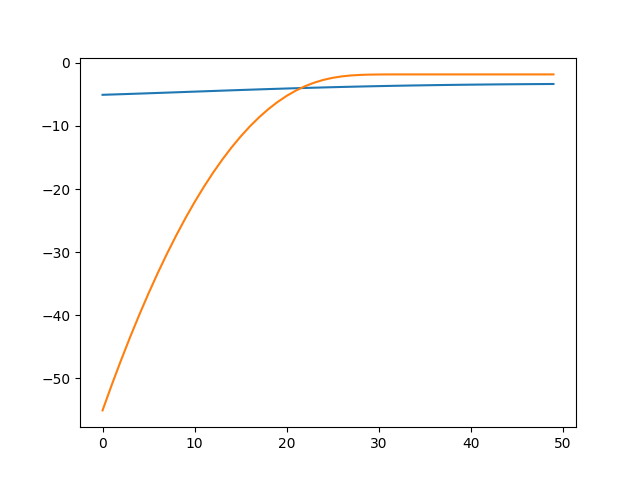

In [7]:
plt.figure()
plt.plot(marg)
plt.plot(no_marg)


In [122]:
from scipy.special import erf
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize
from matplotlib import cm
import numpy as np
from scipy.special import erfc, erfcx, log_ndtr

def lognorm_pdf(val,mu,sigma):
    """Natural log-likelihood of getting :val: given mean and width parameters from the non-lognormal distribution.
    """
    sigma = np.atleast_1d(sigma)
    mu = np.atleast_1d(mu)
    val = np.atleast_1d(val)
    
    mu_X = np.log(mu**2 / np.sqrt(mu**2 + sigma**2)) 
    sigma_X = np.log(1 + mu**2 / sigma**2)
    pdf = -(np.log(val) - mu_X)**2 / (2 * sigma_X**2) - 0.5 * np.log(2 * np.pi * np.abs(sigma)**2) - 1 / val
    return pdf

def lognormal_prior(val,lnmu,lnsigma):
    """    Uses first axis as sigma, second axis for mu values, third axis for the realized DM values."""
    ans = (
        -(
            np.log(val)[None,None,:] - lnmu[None,:,None]
        )**2 
        / (
            2 * lnsigma[:,None,None]**2
          ) 
        - 0.5 * np.log(2 * np.pi * np.abs(lnsigma)[:,None,None]**2) 
        - 1 / val[None,None,:]
    )
    return ans

def log_likelihood_lognorm(dm_frb = 300,
        dm_cosmic = 100,
        sigma_cosmic = 20,
        dm_model = 200,
        sigma_model = 20,
        lnmu = np.log(np.linspace(1,200,num = 30)),
        lnsigma = np.log(np.linspace(0,1,num = 10)),
    ):
    """
    Constructs PDFs for cosmic & CGM model (each has shape (n_dm)),
    Calculates PDF as a function of DM_cbm
    Applies a log-normal prior for DM_cbm (depending on hyperparameters <dm_cbm_i>, <sigma_cbm>)
    Returns P(<dm_cbm_i>,<sigma_cbm>) as a function of hyperparameters
    """

    # construct PDFs
    dm_vals = np.linspace(0,2000,num = 300)
    cosmic_lpdf = lognorm_pdf(dm_vals, mu=dm_cosmic, sigma=sigma_cosmic)
    model_lpdf = lognorm_pdf(dm_vals, mu=dm_model, sigma=sigma_model)
    
    # calculate other PDFs    
    dm2_vals = np.concatenate((dm_vals[:-1],dm_vals + dm_vals[-1])) # DM_cosmic + DM_model (x values)
    dm2_lnpdf = np.log(ss.convolve(np.exp(cosmic_lpdf), np.exp(model_lpdf))) # PDF of (DM_cosmic + DM_model) (y values)

    # construct DM_cbm PDF and cbm prior
    dm3_vals = dm_frb - dm2_vals # DM_cbm x values
    dm3_lnpdf = dm2_lnpdf # a mere relabeling of the x axis 
    cbm_prior = lognormal_prior(dm3_vals, lnmu = lnmu, lnsigma = lnsigma) # DM_cbm PDF values (n_dm_cbm)
    return dm3_lnpdf[None,None,:] + cbm_prior[:,:,:]

#def run_analysis(df):
verbose = False
if verbose:
    plt.figure()
    plt.plot(dm_vals,np.exp(cosmic_lpdf),label = 'DM_cosmic')
    plt.plot(dm_vals,np.exp(model_lpdf),label = 'DM_model')
    plt.plot(dm2_vals,np.log(dm2_pdf),label = 'DM_cosmic + DM_model')
    plt.plot(dm3_vals,np.log(dm2_pdf),label = 'DM_cbm')
    plt.legend()

import pandas as pd
import dmh_tools
import os
ROOT_PATH = os.getcwd() + '/../'
_df = pd.read_csv(os.path.join(ROOT_PATH,'data_products/remove_clusters_lowdm_edgeon.csv'))
_df.set_index('name',inplace=True)
keep = dmh_tools.not_clusters(_df) * dmh_tools.not_edge_on(_df) * dmh_tools.not_scattered(_df) * dmh_tools.not_elliptical(_df) * dmh_tools.not_low_dm(_df) * dmh_tools.not_dwarf(_df)
df = _df[keep]
ll_per_burst = np.zeros((len(df),10,30,599))
for ii,(name,row) in enumerate(df.iterrows()):
    ll_per_burst[ii] = log_likelihood_lognorm(
        dm_frb = row['DM'] - row['DM_NE2001'],
        dm_cosmic = row['dm_igm'],
        sigma_cosmic = dmh_tools.sigma_igm_walker2024(row['primary_z_spec']),
        dm_model = 30,
        sigma_model = 30)

/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_89120/2816869991.py:42: RuntimeWarning: divide by zero encountered in log
  lnsigma = np.log(np.linspace(0,1,num = 10)),
/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_89120/2816869991.py:19: RuntimeWarning: divide by zero encountered in log
  pdf = -(np.log(val) - mu_X)**2 / (2 * sigma_X**2) - 0.5 * np.log(2 * np.pi * np.abs(sigma)**2) - 1 / val
/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_89120/2816869991.py:19: RuntimeWarning: divide by zero encountered in divide
  pdf = -(np.log(val) - mu_X)**2 / (2 * sigma_X**2) - 0.5 * np.log(2 * np.pi * np.abs(sigma)**2) - 1 / val
/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_89120/2816869991.py:58: RuntimeWarning: divide by zero encountered in log
  dm2_lnpdf = np.log(ss.convolve(np.exp(cosmic_lpdf), np.exp(model_lpdf))) # PDF of (DM_cosmic + DM_model) (y values)
/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_89120/2816869991.py:26: Run

(22, 10, 30, 599)

In [ ]:
k